In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# CSV filename
csv_file = "HiMCM 2025 - World Cup Processed Data"  # <-- CHANGE THIS

# weights MUST sum to 1
weights = {
    "CO2 emissions (Tons)": 0.4,
    "Energy": 0.3,
    "Waste": 0.2,
    "Water": 0.1
}

In [ ]:
import pandas as pd
import numpy as np

# Reload the CSV file and strip whitespace from column names
df = pd.read_csv("HiMCM 2025 - World Cup Processed Data.csv")
df.columns = df.columns.str.strip()

# Clean 'CO2' column
df["CO2"] = df["CO2"].astype(str).str.replace("net 0", "0", regex=False) # Replace 'net 0' with '0'
df["CO2"] = df["CO2"].astype(str).str.replace(",", "", regex=False) # Remove commas
df["CO2"] = pd.to_numeric(df["CO2"], errors='coerce') # Convert to numeric, coercing errors
df["CO2"] = df["CO2"].replace(0, np.nan) # Convert numeric 0 to NaN

# Clean 'Energy' column
df["Energy"] = df["Energy"].astype(str).str.replace(",", "", regex=False) # Remove commas
df["Energy"] = pd.to_numeric(df["Energy"], errors='coerce') # Ensure numeric

# Clean 'Waste' column
df["Waste"] = df["Waste"].astype(str).str.replace("%", "", regex=False) # Remove percentage sign
df["Waste"] = pd.to_numeric(df["Waste"], errors='coerce') # Convert to numeric

# Clean 'Water' column: remove commas and convert to numeric
df["Water"] = df["Water"].astype(str).str.replace(",", "", regex=False) # Remove commas
df["Water"] = pd.to_numeric(df["Water"], errors='coerce') # Ensure numeric

# Fill NaN values with the mean of their respective columns, or 0 if mean is NaN
for col in ["CO2", "Energy", "Waste", "Water"]:
    if df[col].isnull().any(): # Check if there are any NaN values in the column
        mean_value = df[col].mean()
        # If mean_value is NaN (meaning the entire column is NaN after numeric conversion),
        # fill with 0 to prevent NaN propagation, as no valid mean can be calculated.
        if pd.isna(mean_value):
            df[col] = df[col].fillna(0)
        else:
            df[col] = df[col].fillna(mean_value)

# Assert that required columns exist
required_cols = ["CO2", "Energy", "Waste", "Water"]
assert all(col in df.columns for col in required_cols), \
    f"CSV must contain: {required_cols}"

# Define normalization function
def normalize(series):
    min_val = series.min()
    max_val = series.max()
    if pd.isna(min_val) or pd.isna(max_val): # If series is all NaNs, min/max will be NaN
        return series * np.nan # Propagate NaNs for a fully NaN series
    if max_val == min_val: # All values are the same
        if min_val == 0: # If all values are 0, normalize to 0 (best possible)
            return series.apply(lambda x: 0)
        else: # If all values are a constant non-zero, normalize to 0.5 (neutral)
            return series.apply(lambda x: 0.5)
    return np.clip((series - min_val) / (max_val - min_val), 0, 1)

# Normalize columns
df["n_CO2"] = normalize(df["CO2"])
df["n_Energy"] = normalize(df["Energy"])
df["n_Waste"] = normalize(df["Waste"])
df["n_Water"] = normalize(df["Water"])

# Calculate scores (assuming higher is better for environmental impact)
df["CO2_score"]   = 1 - df["n_CO2"]
df["Energy_score"] = 1 - df["n_Energy"]
df["Waste_score"] = 1 - df["n_Waste"]
df["Water_score"] = 1 - df["n_Water"]

# Calculate Final Score using pre-defined weights
# weights MUST sum to 1
weights = {
    "CO2 emissions (Tons)": 0.4,
    "Energy": 0.3,
    "Waste": 0.2,
    "Water": 0.1
}

df["Final_Score"] = 100 * (
    weights["CO2 emissions (Tons)"] * df["CO2_score"] +
    weights["Energy"]  * df["Energy_score"] +
    weights["Waste"]   * df["Waste_score"] +
    weights["Water"]   * df["Water_score"]
)

# Display the first 5 rows of the DataFrame
df.head()

,Location for Football Tourney,CO2,Energy,Waste,Water,n_CO2,n_Energy,n_Waste,n_Water,CO2_score,Energy_score,Waste_score,Water_score,Final_Score
0,Qatar 2022,3810000,3466000,10,612900,1.000000,0.866,0.0000,0.283148,0.000000,0.134,1.0000,0.716852,31.188519
1,Russia 2018,2100000,3600000,23,613000,0.447674,1.000,0.1625,0.283333,0.552326,0.000,0.8375,0.716667,46.009690
2,Brazil 2014,2720000,3000000,10,740000,0.647933,0.400,0.0000,0.518519,0.352067,0.600,1.0000,0.481481,56.897502
3,South Africa 2010,1650000,3470000,34,460000,0.302326,0.870,0.3000,0.000000,0.697674,0.130,0.7000,1.000000,55.806977
4,Germany 2006,714000,2600000,50,527000,0.000000,0.000,0.5000,0.124074,1.000000,1.000,0.5000,0.875926,88.759259


In [ ]:
temp_raw_worldcup_df = pd.read_csv("HiMCM 2025 - World Cup Processed Data.csv")
temp_raw_worldcup_df.columns = temp_raw_worldcup_df.columns.str.strip()

print("Raw 'CO2' column sample (first 10 unique non-numeric values and 'net 0' check):")

# Identify non-numeric values by first converting to string and then coercing to numeric
# This helps catch 'net 0' and other string representations of numbers
co2_as_string = temp_raw_worldcup_df['CO2'].astype(str)
non_numeric_co2_initial = co2_as_string[pd.to_numeric(co2_as_string, errors='coerce').isna()]

# Also explicitly check for 'net 0'
if 'net 0' in co2_as_string.unique():
    print("\n'net 0' string value explicitly found in CO2 column.")

# Print other unique non-numeric values
if not non_numeric_co2_initial.empty:
    print("Other unique non-numeric CO2 values (before full cleaning):")
    print(non_numeric_co2_initial.head(10).unique())
else:
    print("No other unique non-numeric CO2 values (before full cleaning) found.")


# Prepare CO2 column for numeric check by first cleaning 'net 0' and commas
cleaned_co2_for_check = temp_raw_worldcup_df['CO2'].astype(str).str.replace('net 0', '0', regex=False)
cleaned_co2_for_check = cleaned_co2_for_check.str.replace(',', '', regex=False)
co2_numeric_check_final = pd.to_numeric(cleaned_co2_for_check, errors='coerce')

print("\nChecking for numeric '0' after initial string cleaning and coercion:")
if 0 in co2_numeric_check_final.unique():
    print(f"The numeric value '0' exists in the 'CO2' column after cleaning 'net 0' and commas.")
else:
    print(f"The numeric value '0' does not exist in the 'CO2' column after cleaning 'net 0' and commas.")

Raw 'CO2' column sample (first 10 unique non-numeric values and 'net 0' check):
Other unique non-numeric CO2 values (before full cleaning):
['3,810,000' '2,100,000' '2,720,000' '1,650,000' '714,000' '3,800,000'
 '3,200,000' '2,800,000' '3,459,000' '2,200,000']

Checking for numeric '0' after initial string cleaning and coercion:
The numeric value '0' does not exist in the 'CO2' column after cleaning 'net 0' and commas.


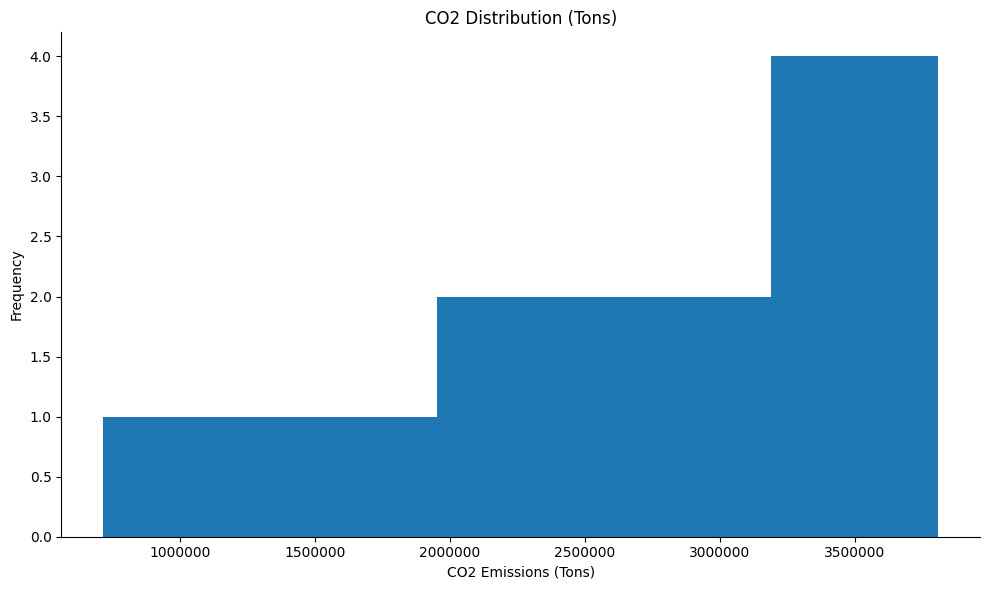

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Histogram for CO2 Distribution
fig_co2, ax_co2 = plt.subplots(figsize=(10, 6))
df['CO2'].plot(kind='hist', bins=5, title='CO2 Distribution (Tons)', ax=ax_co2)
ax_co2.spines[['top', 'right']].set_visible(False)
formatter_co2 = mticker.ScalarFormatter(useOffset=False, useMathText=False)
formatter_co2.set_scientific(False)
ax_co2.xaxis.set_major_formatter(formatter_co2)
plt.xlabel('CO2 Emissions (Tons)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

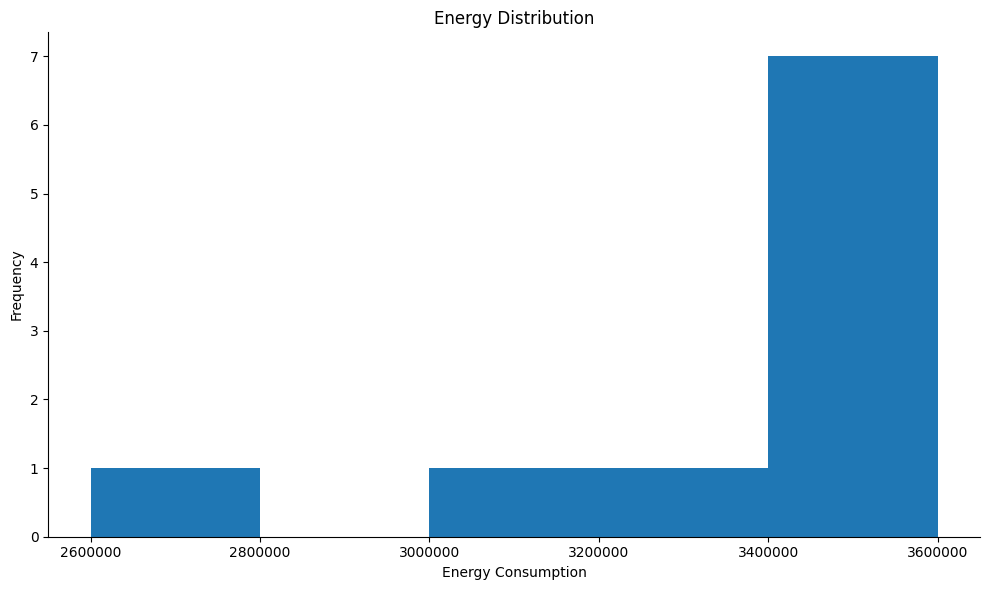

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Histogram for Energy Distribution
fig_energy, ax_energy = plt.subplots(figsize=(10, 6))
df['Energy'].plot(kind='hist', bins=5, title='Energy Distribution', ax=ax_energy)
ax_energy.spines[['top', 'right']].set_visible(False)
formatter_energy = mticker.ScalarFormatter(useOffset=False, useMathText=False)
formatter_energy.set_scientific(False)
ax_energy.xaxis.set_major_formatter(formatter_energy)
plt.xlabel('Energy Consumption')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

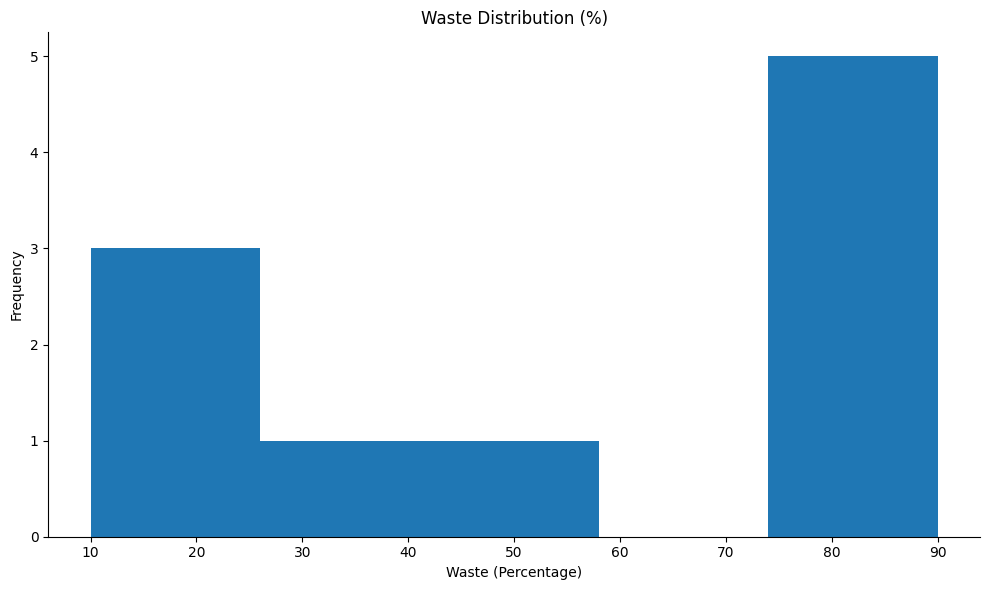

In [ ]:
import matplotlib.pyplot as plt

# Histogram for Waste Distribution
fig_waste, ax_waste = plt.subplots(figsize=(10, 6))
df['Waste'].plot(kind='hist', bins=5, title='Waste Distribution (%)', ax=ax_waste)
ax_waste.spines[['top', 'right']].set_visible(False)
plt.xlabel('Waste (Percentage)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

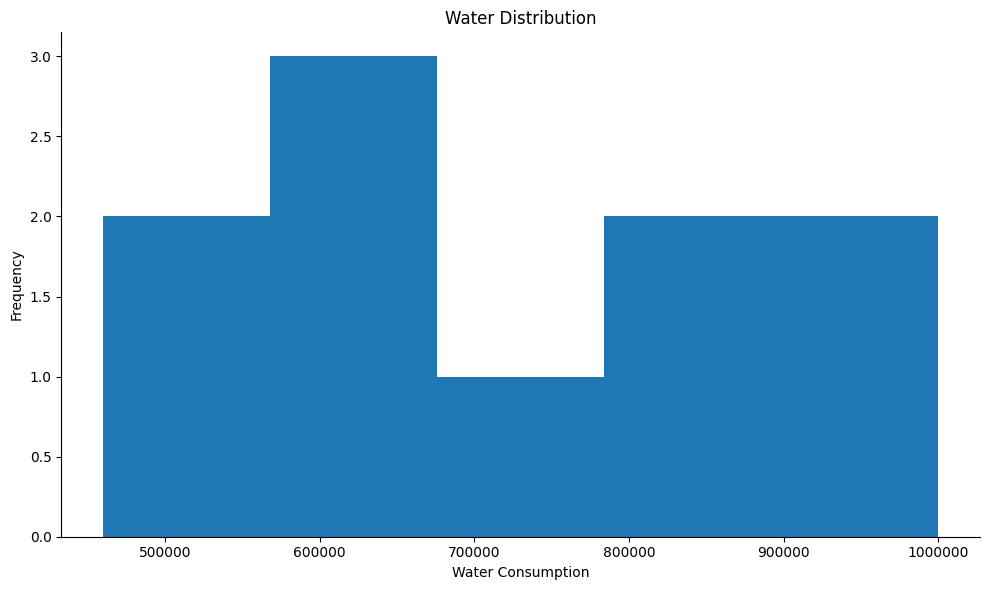

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Histogram for Water Distribution
fig_water, ax_water = plt.subplots(figsize=(10, 6))
df['Water'].plot(kind='hist', bins=5, title='Water Distribution', ax=ax_water)
ax_water.spines[['top', 'right']].set_visible(False)
formatter_water = mticker.ScalarFormatter(useOffset=False, useMathText=False)
formatter_water.set_scientific(False)
ax_water.xaxis.set_major_formatter(formatter_water)
plt.xlabel('Water Consumption')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Reload the CSV file and strip whitespace from column names
df = pd.read_csv("HiMCM 2025 - World Cup Processed Data.csv")
df.columns = df.columns.str.strip()

# Clean 'CO2' column
df["CO2"] = df["CO2"].astype(str).str.replace("net 0", "0", regex=False) # Replace 'net 0' with '0'
df["CO2"] = df["CO2"].astype(str).str.replace(",", "", regex=False) # Remove commas
df["CO2"] = pd.to_numeric(df["CO2"], errors='coerce') # Convert to numeric, coercing errors
df["CO2"] = df["CO2"].replace(0, np.nan) # Convert numeric 0 to NaN

# Clean 'Energy' column
df["Energy"] = df["Energy"].astype(str).str.replace(",", "", regex=False) # Remove commas
df["Energy"] = pd.to_numeric(df["Energy"], errors='coerce') # Ensure numeric

# Clean 'Waste' column
df["Waste"] = df["Waste"].astype(str).str.replace("%", "", regex=False) # Remove percentage sign
df["Waste"] = pd.to_numeric(df["Waste"], errors='coerce') # Convert to numeric

# Clean 'Water' column: remove commas and convert to numeric
df["Water"] = df["Water"].astype(str).str.replace(",", "", regex=False) # Remove commas
df["Water"] = pd.to_numeric(df["Water"], errors='coerce') # Ensure numeric

# Fill NaN values with the mean of their respective columns, or 0 if mean is NaN
for col in ["CO2", "Energy", "Waste", "Water"]:
    if df[col].isnull().any(): # Check if there are any NaN values in the column
        mean_value = df[col].mean()
        # If mean_value is NaN (meaning the entire column is NaN after numeric conversion),
        # fill with 0 to prevent NaN propagation, as no valid mean can be calculated.
        if pd.isna(mean_value):
            df[col] = df[col].fillna(0)
        else:
            df[col] = df[col].fillna(mean_value)

# Assert that required columns exist
required_cols = ["CO2", "Energy", "Waste", "Water"]
assert all(col in df.columns for col in required_cols), \
    f"CSV must contain: {required_cols}"

# Define normalization function (robust to constant series)
def normalize(series):
    min_val = series.min()
    max_val = series.max()
    if pd.isna(min_val) or pd.isna(max_val): # If series is all NaNs, min/max will be NaN
        return series * np.nan # Propagate NaNs for a fully NaN series
    if max_val == min_val: # All values are the same
        if min_val == 0: # If all values are 0, normalize to 0 (best possible)
            return series.apply(lambda x: 0)
        else: # If all values are a constant non-zero, normalize to 0.5 (neutral)
            return series.apply(lambda x: 0.5)
    return np.clip((series - min_val) / (max_val - min_val), 0, 1)

# Normalize columns
df["n_CO2"] = normalize(df["CO2"])
df["n_Energy"] = normalize(df["Energy"])
df["n_Waste"] = normalize(df["Waste"])
df["n_Water"] = normalize(df["Water"])

# Calculate scores (assuming higher is better for environmental impact)
df["CO2_score"]   = 1 - df["n_CO2"]
df["Energy_score"] = 1 - df["n_Energy"]
df["Waste_score"] = 1 - df["n_Waste"]
df["Water_score"] = 1 - df["n_Water"]

# Calculate Final Score using pre-defined weights
# weights MUST sum to 1
# Assuming weights are already defined in the kernel from previous cells, if not, define here:
weights = {
    "CO2 emissions (Tons)": 0.4,
    "Energy": 0.3,
    "Waste": 0.2,
    "Water": 0.1
}

df["Final_Score"] = 100 * (
    weights["CO2 emissions (Tons)"] * df["CO2_score"] +
    weights["Energy"]  * df["Energy_score"] +
    weights["Waste"]   * df["Waste_score"] +
    weights["Water"]   * df["Water_score"]
)

# Display the first 5 rows of the DataFrame
df.head()

,Location for Football Tourney,CO2,Energy,Waste,Water,n_CO2,n_Energy,n_Waste,n_Water,CO2_score,Energy_score,Waste_score,Water_score,Final_Score
0,Qatar 2022,3810000,3466000,10,612900,1.000000,0.866,0.0000,0.283148,0.000000,0.134,1.0000,0.716852,31.188519
1,Russia 2018,2100000,3600000,23,613000,0.447674,1.000,0.1625,0.283333,0.552326,0.000,0.8375,0.716667,46.009690
2,Brazil 2014,2720000,3000000,10,740000,0.647933,0.400,0.0000,0.518519,0.352067,0.600,1.0000,0.481481,56.897502
3,South Africa 2010,1650000,3470000,34,460000,0.302326,0.870,0.3000,0.000000,0.697674,0.130,0.7000,1.000000,55.806977
4,Germany 2006,714000,2600000,50,527000,0.000000,0.000,0.5000,0.124074,1.000000,1.000,0.5000,0.875926,88.759259


In [17]:
display(df[['Location for Football Tourney', 'Final_Score']])

,Location for Football Tourney,Final_Score
0,Qatar 2022,31.188519
1,Russia 2018,46.009690
2,Brazil 2014,56.897502
3,South Africa 2010,55.806977
4,Germany 2006,88.759259
5,South Korea & Japan 2002,16.562903
6,France 1998,13.881137
7,U.S. 1994,19.902799
8,Italy 1990,17.442291
9,Mexico 1986,27.912145


In [18]:
display(df)

,Location for Football Tourney,CO2,Energy,Waste,Water,n_CO2,n_Energy,n_Waste,n_Water,CO2_score,Energy_score,Waste_score,Water_score,Final_Score
0,Qatar 2022,3810000,3466000,10,612900,1.000000,0.866,0.0000,0.283148,0.000000,0.134,1.0000,0.716852,31.188519
1,Russia 2018,2100000,3600000,23,613000,0.447674,1.000,0.1625,0.283333,0.552326,0.000,0.8375,0.716667,46.009690
2,Brazil 2014,2720000,3000000,10,740000,0.647933,0.400,0.0000,0.518519,0.352067,0.600,1.0000,0.481481,56.897502
3,South Africa 2010,1650000,3470000,34,460000,0.302326,0.870,0.3000,0.000000,0.697674,0.130,0.7000,1.000000,55.806977
4,Germany 2006,714000,2600000,50,527000,0.000000,0.000,0.5000,0.124074,1.000000,1.000,0.5000,0.875926,88.759259
5,South Korea & Japan 2002,3800000,3259000,80,800000,0.996770,0.659,0.8750,0.629630,0.003230,0.341,0.1250,0.370370,16.562903
6,France 1998,3200000,3400000,90,1000000,0.802972,0.800,1.0000,1.000000,0.197028,0.200,0.0000,0.000000,13.881137
7,U.S. 1994,2800000,3570000,75,881000,0.673773,0.970,0.8125,0.779630,0.326227,0.030,0.1875,0.220370,19.902799
8,Italy 1990,3459000,3500000,80,600000,0.886628,0.900,0.8750,0.259259,0.113372,0.100,0.1250,0.740741,17.442291
9,Mexico 1986,2200000,3400000,90,940000,0.479974,0.800,1.0000,0.888889,0.520026,0.200,0.0000,0.111111,27.912145


In [19]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1q1McR2W6sKApT8FImDwSSTT3ex-6-ag-gp-z3E1W7vA/edit#gid=0


In [22]:
columns_to_drop = [col for col in df.columns if col.startswith('n_')]
df = df.drop(columns=columns_to_drop)
display(df.head())

,Location for Football Tourney,CO2,Energy,Waste,Water,CO2_score,Energy_score,Waste_score,Water_score,Final_Score
0,Qatar 2022,3810000,3466000,10,612900,0.000000,0.134,1.0000,0.716852,31.188519
1,Russia 2018,2100000,3600000,23,613000,0.552326,0.000,0.8375,0.716667,46.009690
2,Brazil 2014,2720000,3000000,10,740000,0.352067,0.600,1.0000,0.481481,56.897502
3,South Africa 2010,1650000,3470000,34,460000,0.697674,0.130,0.7000,1.000000,55.806977
4,Germany 2006,714000,2600000,50,527000,1.000000,1.000,0.5000,0.875926,88.759259


In [23]:
display(df[['Location for Football Tourney', 'CO2', 'Energy', 'Waste', 'Water', 'Final_Score']])

,Location for Football Tourney,CO2,Energy,Waste,Water,Final_Score
0,Qatar 2022,3810000,3466000,10,612900,31.188519
1,Russia 2018,2100000,3600000,23,613000,46.009690
2,Brazil 2014,2720000,3000000,10,740000,56.897502
3,South Africa 2010,1650000,3470000,34,460000,55.806977
4,Germany 2006,714000,2600000,50,527000,88.759259
5,South Korea & Japan 2002,3800000,3259000,80,800000,16.562903
6,France 1998,3200000,3400000,90,1000000,13.881137
7,U.S. 1994,2800000,3570000,75,881000,19.902799
8,Italy 1990,3459000,3500000,80,600000,17.442291
9,Mexico 1986,2200000,3400000,90,940000,27.912145
